In [1]:
import numpy as np
from matplotlib import pyplot as plt
import control as ctrl
from scipy.integrate import solve_ivp


# Actuador no lineal

Se tiene un sistema 
$$ G=\frac{1}{(s+1)^3} $$

actuado con una válvula con la siguiente característica

$$ v = u^4$$

y controlado por un PI.

Se desea ver la respuesta del sistema en distintos puntos de trabajo.

Como el sistema es no lineal vamos a necesitar integrar con solve_ivp. Para esto tenemos que expresar el modelo completo en variables de estado.

In [81]:
s = ctrl.tf('s')

# Planta
G = 1/(s+1)**3

# Controlador
Ti = 1
Kp = 0.15
C = Kp*(1+1/(Ti*s))

# Pero así como está no puedo simular porque tengo una no linealidad en el medio
Gss = ctrl.tf2ss(G)
A_ = np.asarray(Gss.A)
B_ = np.asarray(Gss.B).flatten()
C_ = np.asarray(Gss.C).flatten()
D_ = float(Gss.D[0][0])

# Armo el modelo a integrar con solve_ivp
# Se incluye la planta, el control y el actuador
def modelo(t, x):    
    xp = x[0:-1]
    xi = x[-1]

    # Salida
    y = C_ @ xp 

    # Error
    e = r - y

    # PI
    u = Kp * (e + xi/Ti)

    # Válvula
    v = u**4

    # Planta
    dx = A_ @ xp + B_ * v
    y = C_ @ xp 

    # Integrador del PI
    d_xi = e

    return np.append(dx, d_xi)

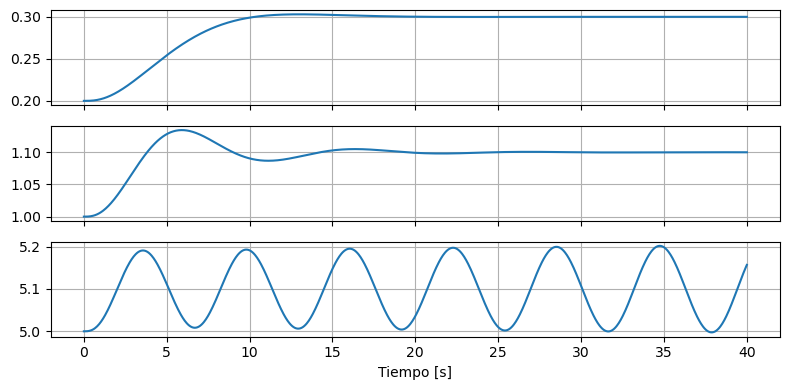

In [90]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(8, 4))

for i,y0 in enumerate([0.2, 1.0, 5.0]):
    # Condición inicial
    u0 = y0**(1/4)
    xi0 = Ti*u0/Kp
    x0 = [0,0,y0,xi0]

    # Referencia
    r = y0+0.1

    # Simulación
    t = np.linspace(0, 40, 1000)
    sol = solve_ivp(
        modelo,
        [t[0], t[-1]],
        x0,
        t_eval=t
    )

    y = C_ @ sol.y[:-1, :]

    ax[i].plot(t, y)
    ax[i].grid()

ax[-1].set_xlabel('Tiempo [s]')
plt.tight_layout()
plt.show()

# Dinámica dependiente del caudal

Se tiene un sistema donde el caudal representa la producción de la planta.
Como el producto tiene que desplazarse cierta distancia entre tanques se tiene un retardo inversamente proporcional al caudal.
$$\tau=\frac{V_d}{q}$$

Además la constante de tiempo del sistema también es inversamente proporcional al caudal.
$$T=\frac{V_m}{q}$$

El modelo de la planta resulta
$$ G_0 = \frac{e^{-s\tau}}{1+sT}$$

Se ajusta un controlador PI para el punto de trabajo en el que $T=\tau=1$

$$Kp= 0.5$$
$$T_i=1.1$$

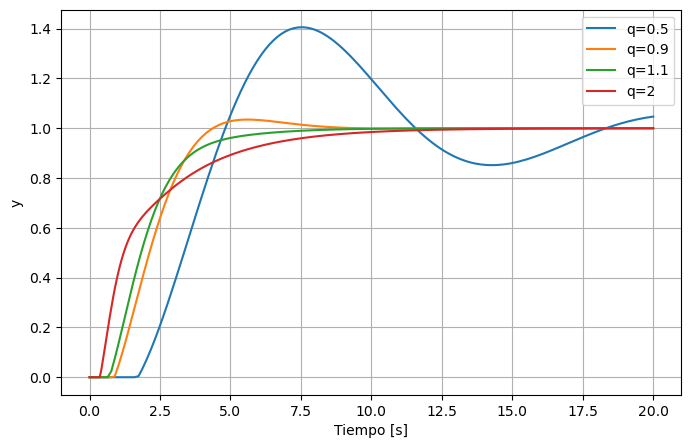

In [19]:

s = ctrl.tf('s')

plt.figure(figsize=(8,5))
for q in [0.5, 0.9, 1.1, 2]:

    # Parámetros
    T = 1/q
    tau = 1/q

    # Planta sin retardo
    G = 1/(1 + T*s)

    # Aproximación de Padé de primer orden
    num_delay, den_delay = ctrl.pade(tau, 1)
    Delay = ctrl.tf(num_delay, den_delay)

    # Planta con retardo aproximado
    G0 = Delay * G

    # Controlador PI
    Kp = 0.5
    Ti = 1.1
    C = Kp*(1+1/(Ti*s))

    Tcl = ctrl.feedback(G0*C)

    # Respuesta al escalón
    t, y = ctrl.step_response(Tcl,T=20)
    y[y<0] = 0

    plt.plot(t, y, label=f'q={q}')

plt.xlabel('Tiempo [s]')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.tight_layout
plt.show()